# Bankruptcy Prediction — Dataset Details & Exploratory Data Analysis

**Objective:** Explore a dataset of 250 companies, each described by 6 qualitative
risk/performance features, in order to understand the patterns that separate
`bankruptcy` from `non-bankruptcy` firms

## 1. Import Libraries

In [25]:
# Core libraries for data handling
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# I/O helper to read the embedded CSV string as if it were a file
from io import StringIO

# Cosmetic settings for nicer plots and output
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

## 2. Load the Dataset

The source file `bankruptcy-prevention.xlsx` stores all 7 fields of every row
as a **single semicolon-separated string in one column**
So we can't just call `pd.read_excel(...)` directly and expect clean columns —
we first read it as a single raw column, then **split each row on `;`** to
recover the 7 individual fields, and finally assign proper column names and
numeric types

In [2]:
# Path to the source Excel file (update this if the file is located elsewhere)
file_path = "bankruptcy-prevention.xlsx"

# Read the raw sheet with no header, since the real header/data is all packed
# into a single column separated by semicolons
raw = pd.read_excel(file_path, header=None)

print("Raw shape (including header row):", raw.shape)
raw.head()

Raw shape (including header row): (251, 5)


,0,1,2,3,4
0,industrial_risk; management_risk; financial_fl...,credibility;,competitiveness;,operating_risk;,class
1,0.5;1;0;0;0;0.5;bankruptcy,NaN,NaN,NaN,NaN
2,0;1;0;0;0;1;bankruptcy,NaN,NaN,NaN,NaN
3,1;0;0;0;0;1;bankruptcy,NaN,NaN,NaN,NaN
4,0.5;0;0;0.5;0;1;bankruptcy,NaN,NaN,NaN,NaN


In [3]:
# The very first row holds the header (also semicolon-separated); the rest are data
header_row = raw.iloc[0, 0]
data_rows = raw.iloc[1:, 0]

print("Raw header string:", header_row)
print("Example raw data string:", data_rows.iloc[0])

Raw header string: industrial_risk; management_risk; financial_flexibility;
Example raw data string: 0.5;1;0;0;0;0.5;bankruptcy


In [4]:
# Final, clean column names for the 6 features + target
column_names = [
    "industrial_risk",
    "management_risk",
    "financial_flexibility",
    "credibility",
    "competitiveness",
    "operating_risk",
    "class",
]

# Split every data row on ';' to recover the 7 individual fields
split_rows = data_rows.str.split(";")

# Build a clean DataFrame from the split values
df = pd.DataFrame(split_rows.tolist(), columns=column_names)

# The first 6 columns are numeric (0 / 0.5 / 1); convert them from strings to floats.
# The 'class' column stays as text (bankruptcy / non-bankruptcy) and just needs stripping.
feature_cols = column_names[:-1]
df[feature_cols] = df[feature_cols].astype(float)
df["class"] = df["class"].str.strip()

# Reset index for a clean 0..249 row index
df = df.reset_index(drop=True)

# Quick look at the first few cleaned rows
df.head(10)

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1.0,0.0,0.0,0.0,0.5,bankruptcy
1,0.0,1.0,0.0,0.0,0.0,1.0,bankruptcy
2,1.0,0.0,0.0,0.0,0.0,1.0,bankruptcy
3,0.5,0.0,0.0,0.5,0.0,1.0,bankruptcy
4,1.0,1.0,0.0,0.0,0.0,1.0,bankruptcy
5,1.0,1.0,0.0,0.5,0.0,0.5,bankruptcy
6,1.0,1.0,0.0,0.0,0.0,0.0,bankruptcy
7,1.0,1.0,0.0,0.0,0.0,0.5,bankruptcy
8,1.0,1.0,0.0,0.5,0.0,0.0,bankruptcy
9,1.0,1.0,0.0,0.5,0.0,1.0,bankruptcy


## 3. Dataset Details

In [5]:
# Shape of the dataset: (rows, columns)
print("Shape of the dataset:", df.shape)
print(f"Number of companies (rows): {df.shape[0]}")
print(f"Number of columns (6 features + 1 target): {df.shape[1]}")

Shape of the dataset: (250, 7)
Number of companies (rows): 250
Number of columns (6 features + 1 target): 7


In [6]:
# Column names and their data types
df.dtypes

industrial_risk          float64
management_risk          float64
financial_flexibility    float64
credibility              float64
competitiveness          float64
operating_risk           float64
class                     object
dtype: object

In [7]:
# General structural information: dtypes, non-null counts, memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   industrial_risk        250 non-null    float64
 1   management_risk        250 non-null    float64
 2   financial_flexibility  250 non-null    float64
 3   credibility            250 non-null    float64
 4   competitiveness        250 non-null    float64
 5   operating_risk         250 non-null    float64
 6   class                  250 non-null    object 
dtypes: float64(6), object(1)
memory usage: 13.8+ KB


In [8]:
# Check for missing (null) values in every column
df.isnull().sum()

industrial_risk          0
management_risk          0
financial_flexibility    0
credibility              0
competitiveness          0
operating_risk           0
class                    0
dtype: int64

In [9]:
# Check for duplicate rows in the dataset
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 147


In [10]:
# Unique values taken by each qualitative feature (should be 0, 0.5, 1)
feature_cols = ["industrial_risk", "management_risk", "financial_flexibility",
                 "credibility", "competitiveness", "operating_risk"]

for col in feature_cols:
    print(f"{col}: {sorted(df[col].unique())}")

industrial_risk: [np.float64(0.0), np.float64(0.5), np.float64(1.0)]
management_risk: [np.float64(0.0), np.float64(0.5), np.float64(1.0)]
financial_flexibility: [np.float64(0.0), np.float64(0.5), np.float64(1.0)]
credibility: [np.float64(0.0), np.float64(0.5), np.float64(1.0)]
competitiveness: [np.float64(0.0), np.float64(0.5), np.float64(1.0)]
operating_risk: [np.float64(0.0), np.float64(0.5), np.float64(1.0)]


In [11]:
# Statistical summary of the numeric (feature) columns
df.describe()

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,0.518000,0.614000,0.376000,0.470000,0.476000,0.570000
std,0.411526,0.410705,0.401583,0.415682,0.440682,0.434575
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000
50%,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000
75%,1.000000,1.000000,0.500000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
# Distribution of the target variable 'class'
df["class"].value_counts()

class
non-bankruptcy    143
bankruptcy        107
Name: count, dtype: int64

In [13]:
# Same distribution as percentages
df["class"].value_counts(normalize=True) * 100

class
non-bankruptcy    57.2
bankruptcy        42.8
Name: proportion, dtype: float64

## 4. Target Variable Analysis (`class`)

Since this is a classification problem, it's important to check whether the
two classes (`bankruptcy` vs `non-bankruptcy`) are balanced. A large imbalance
would need to be handled later (e.g. with resampling or class weights).


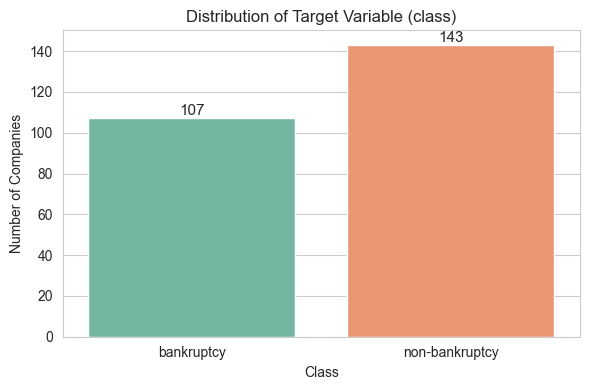

In [14]:
# Bar chart of class distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="class", hue="class", palette="Set2", legend=False)
ax.set_title("Distribution of Target Variable (class)")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Companies")

# Annotate each bar with its exact count
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

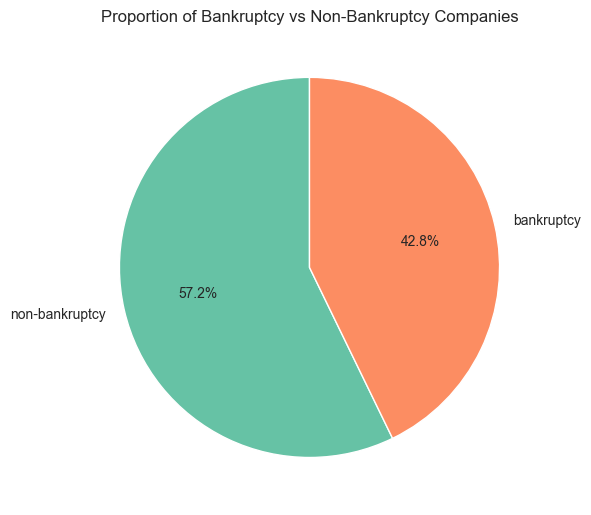

In [15]:
# Pie chart view of the same distribution (proportions)
plt.figure(figsize=(6, 6))
class_counts = df["class"].value_counts()
plt.pie(class_counts, labels=class_counts.index, autopct="%1.1f%%",
        colors=sns.color_palette("Set2"), startangle=90)
plt.title("Proportion of Bankruptcy vs Non-Bankruptcy Companies")
plt.tight_layout()
plt.show()

**Observation:** The dataset is moderately imbalanced (roughly 57% non-bankruptcy
vs 43% bankruptcy), but not severely so — standard classification models should
be able to handle this without special resampling techniques, though it's worth
keeping in mind when choosing evaluation metrics (e.g. prefer F1-score / recall
over plain accuracy).

## 5. Univariate Analysis — Individual Feature Distributions

Each feature only takes 3 possible values (0 = low, 0.5 = medium, 1 = high).
Here we look at how companies are spread across these levels, one feature at a time.


In [16]:
# Value counts for every feature (how many companies fall into low/medium/high)
for col in feature_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts().sort_index())
    print()

--- industrial_risk ---
industrial_risk
0.0    80
0.5    81
1.0    89
Name: count, dtype: int64

--- management_risk ---
management_risk
0.0     62
0.5     69
1.0    119
Name: count, dtype: int64

--- financial_flexibility ---
financial_flexibility
0.0    119
0.5     74
1.0     57
Name: count, dtype: int64

--- credibility ---
credibility
0.0    94
0.5    77
1.0    79
Name: count, dtype: int64

--- competitiveness ---
competitiveness
0.0    103
0.5     56
1.0     91
Name: count, dtype: int64

--- operating_risk ---
operating_risk
0.0     79
0.5     57
1.0    114
Name: count, dtype: int64



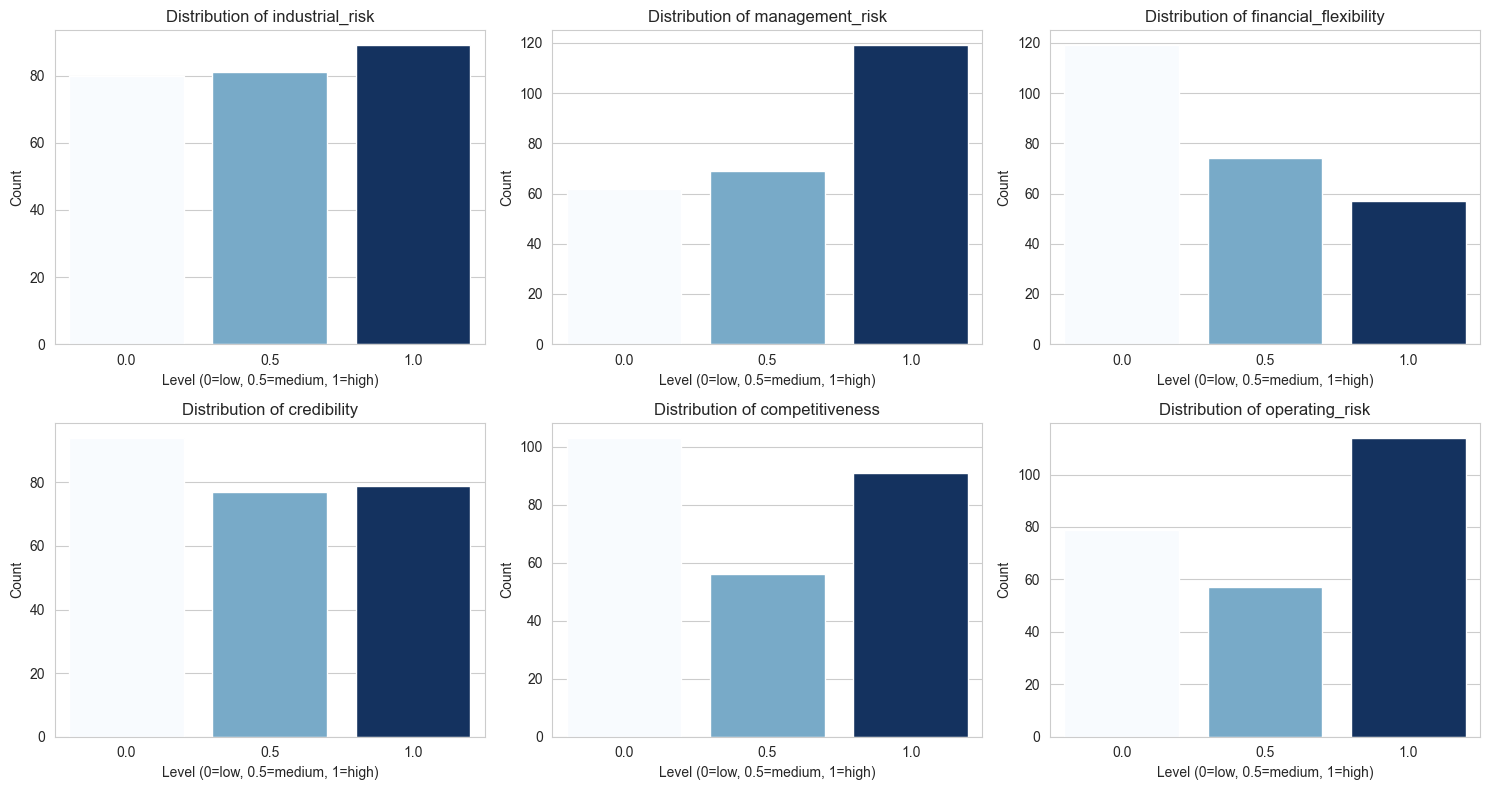

In [17]:
# Grid of bar charts: one subplot per feature showing its distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.countplot(data=df, x=col, hue=col, palette="Blues", legend=False, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel("Level (0=low, 0.5=medium, 1=high)")
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 6. Bivariate Analysis — Features vs. Target (`class`)

This is the key part of the EDA: for each feature, we check whether its level
(low/medium/high) tends to differ between bankrupt and non-bankrupt companies.
A clear separation here is a strong hint that the feature will be predictive.


In [18]:
# Cross-tabulation of each feature against the target class
for col in feature_cols:
    print(f"--- {col} vs class ---")
    ct = pd.crosstab(df[col], df["class"])
    print(ct)
    print()

--- industrial_risk vs class ---
class            bankruptcy  non-bankruptcy
industrial_risk                            
0.0                      26              54
0.5                      28              53
1.0                      53              36

--- management_risk vs class ---
class            bankruptcy  non-bankruptcy
management_risk                            
0.0                      11              51
0.5                      23              46
1.0                      73              46

--- financial_flexibility vs class ---
class                  bankruptcy  non-bankruptcy
financial_flexibility                            
0.0                           102              17
0.5                             4              70
1.0                             1              56

--- credibility vs class ---
class        bankruptcy  non-bankruptcy
credibility                            
0.0                  87               7
0.5                  17              60
1.0          

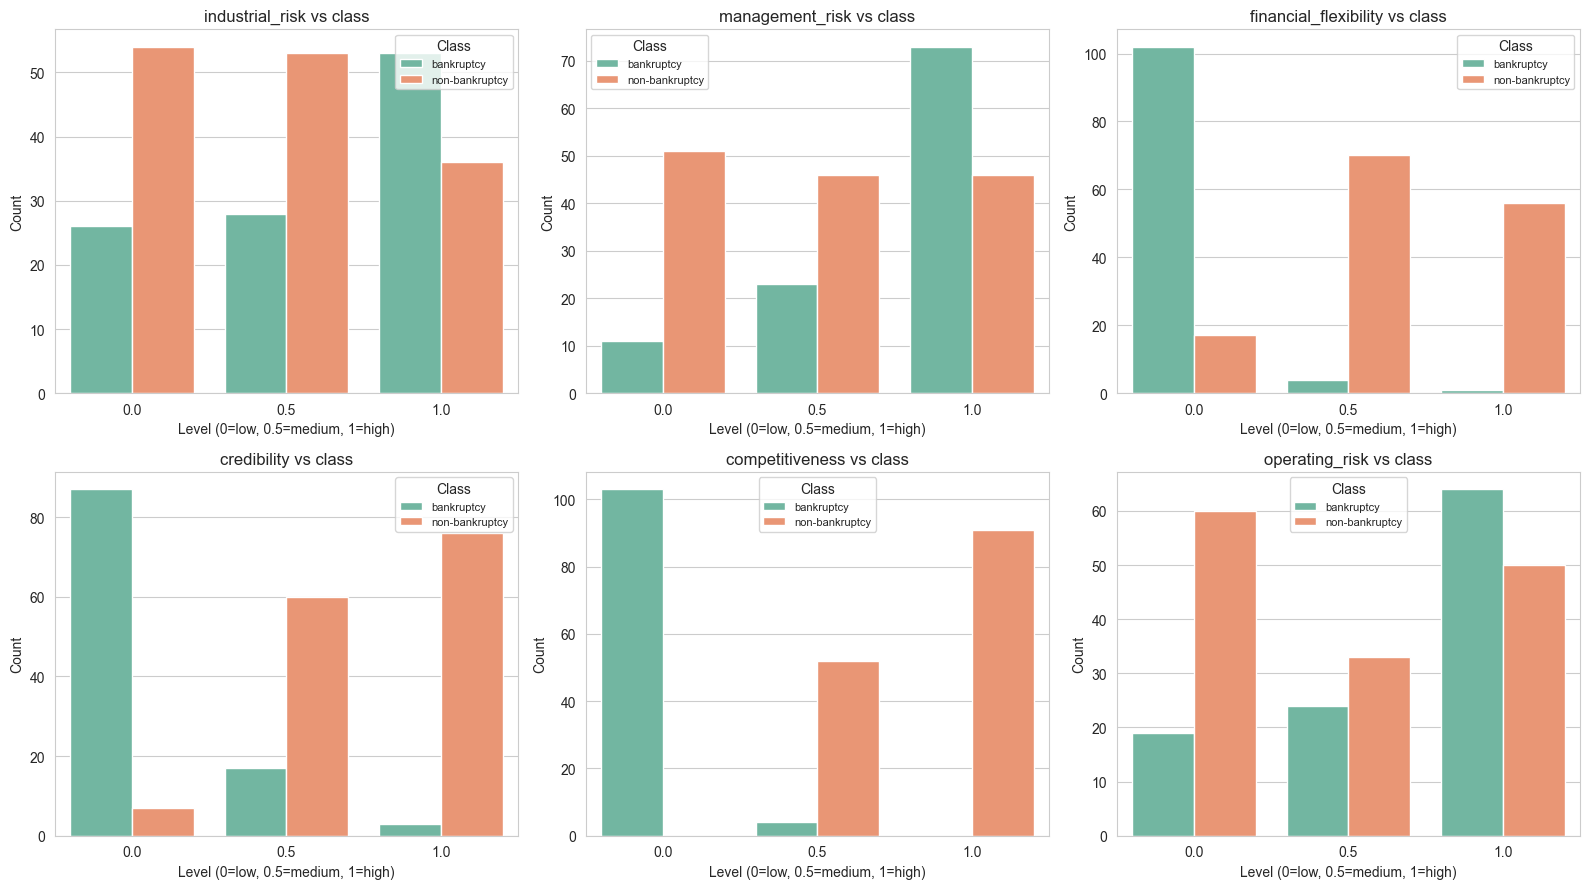

In [19]:
# Grid of grouped bar charts: feature level vs class, one subplot per feature
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.countplot(data=df, x=col, hue="class", palette="Set2", ax=axes[i])
    axes[i].set_title(f"{col} vs class")
    axes[i].set_xlabel("Level (0=low, 0.5=medium, 1=high)")
    axes[i].set_ylabel("Count")
    axes[i].legend(title="Class", fontsize=8)

plt.tight_layout()
plt.show()

**Observation:** For most features — especially `management_risk`,
`financial_flexibility`, `credibility`, and `competitiveness` — bankrupt
companies are concentrated at the "low" (0) level while non-bankrupt companies
are concentrated at "medium/high" (0.5 / 1) levels. This suggests these
features carry strong predictive signal.

## 7. Correlation Analysis

Since all 6 features are numeric (0 / 0.5 / 1), we can compute a correlation
matrix directly. We also encode the target as a binary numeric column
(`class_binary`) purely for this correlation check.


In [20]:
# Encode target as binary purely for correlation analysis (1 = bankruptcy, 0 = non-bankruptcy)
df["class_binary"] = df["class"].map({"bankruptcy": 1, "non-bankruptcy": 0})

# Compute the correlation matrix (features + encoded target)
corr_matrix = df[feature_cols + ["class_binary"]].corr()
corr_matrix

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class_binary
industrial_risk,1.000000,0.255127,-0.162624,-0.014438,-0.257814,0.144507,0.227823
management_risk,0.255127,1.000000,-0.254845,-0.303341,-0.306568,0.213874,0.370838
financial_flexibility,-0.162624,-0.254845,1.000000,0.524951,0.686612,-0.116903,-0.751020
credibility,-0.014438,-0.303341,0.524951,1.000000,0.675689,-0.288458,-0.755909
competitiveness,-0.257814,-0.306568,0.686612,0.675689,1.000000,-0.211383,-0.899452
operating_risk,0.144507,0.213874,-0.116903,-0.288458,-0.211383,1.000000,0.279786
class_binary,0.227823,0.370838,-0.751020,-0.755909,-0.899452,0.279786,1.000000


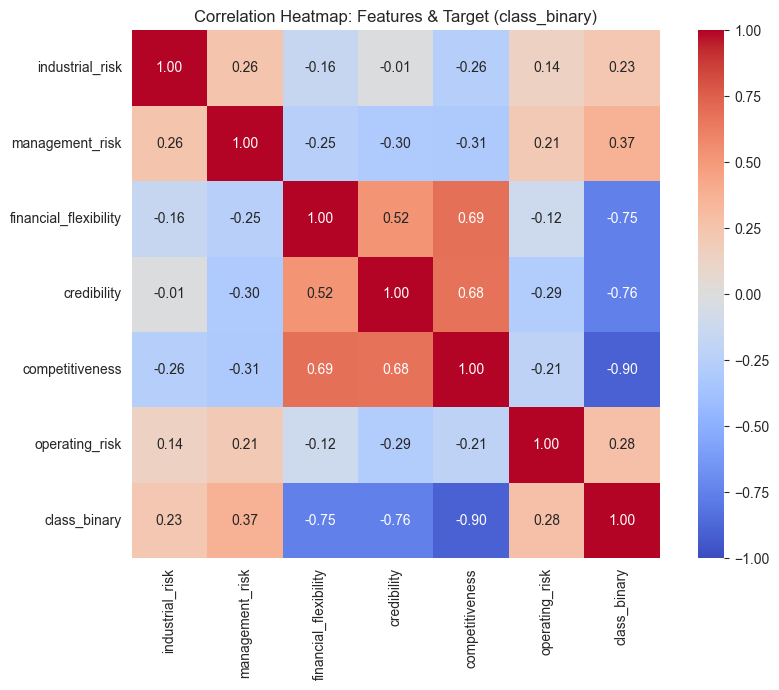

In [21]:
# Heatmap visualization of the correlation matrix
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation Heatmap: Features & Target (class_binary)")
plt.tight_layout()
plt.show()

In [22]:
# Rank features by absolute correlation with the target (most predictive first)
target_corr = corr_matrix["class_binary"].drop("class_binary").sort_values(key=abs, ascending=False)
target_corr

competitiveness         -0.899452
credibility             -0.755909
financial_flexibility   -0.751020
management_risk          0.370838
operating_risk           0.279786
industrial_risk          0.227823
Name: class_binary, dtype: float64

## 8. Multivariate View — Pairwise Relationships Coloured by Class

A pairplot lets us look at several feature combinations at once and see how
well the two classes separate across pairs of features.


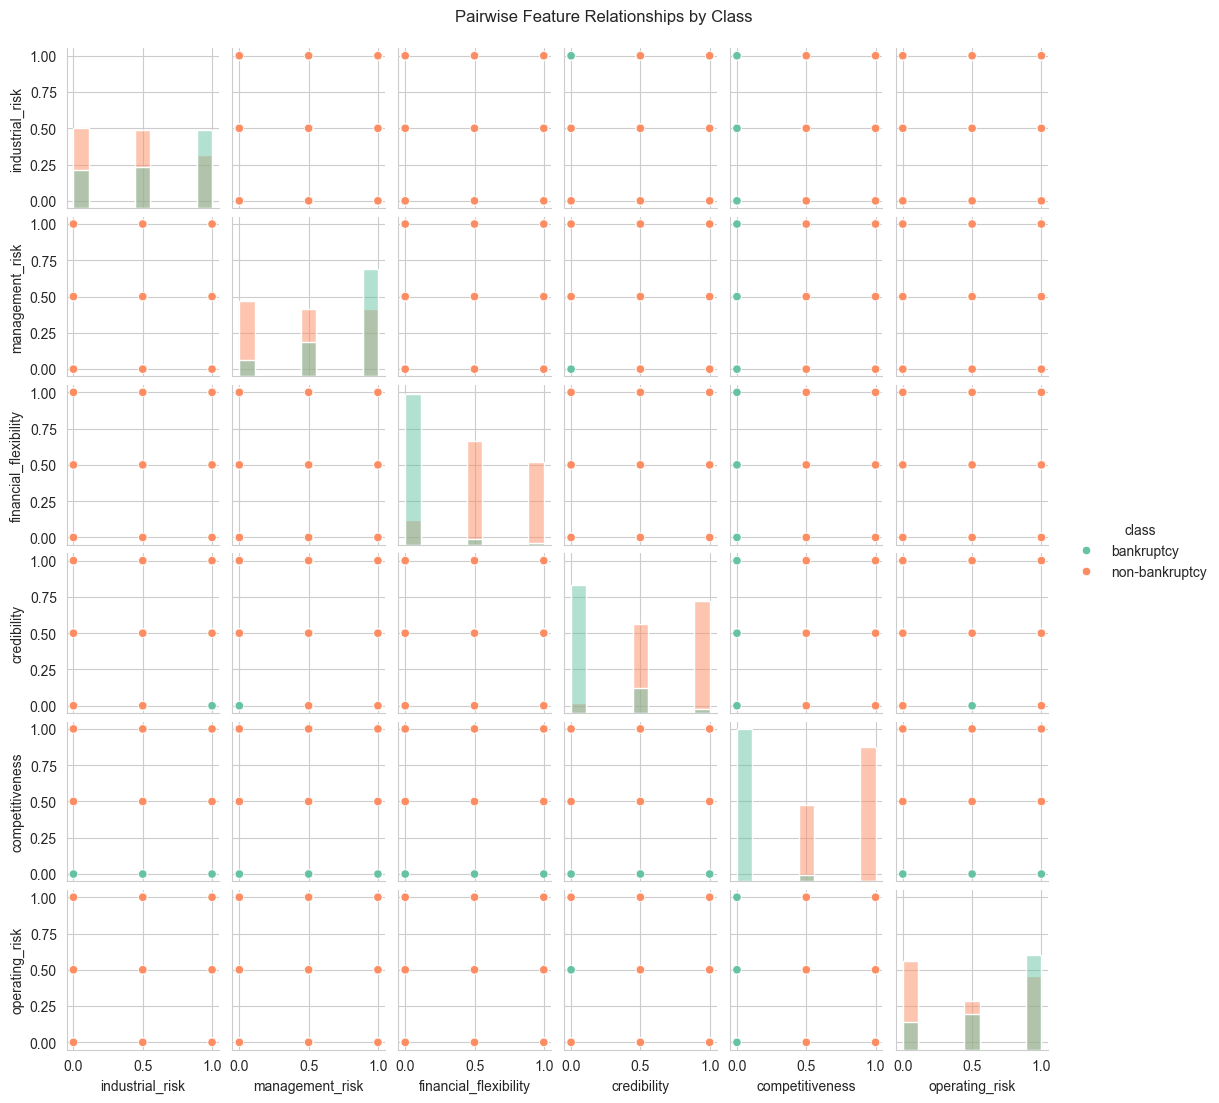

In [23]:
# Pairplot of all 6 features, coloured by class (subsample of features shown for clarity)
sns.pairplot(df, vars=feature_cols, hue="class", palette="Set2", diag_kind="hist", height=1.8)
plt.suptitle("Pairwise Feature Relationships by Class", y=1.02)
plt.show()

## 9. Simple Derived View — Average Risk vs Average Strength

As a sanity check, we combine the three "risk" features (industrial, management,
operating) into one average, and the three "strength" features (financial
flexibility, credibility, competitiveness) into another, and compare their
distributions by class.


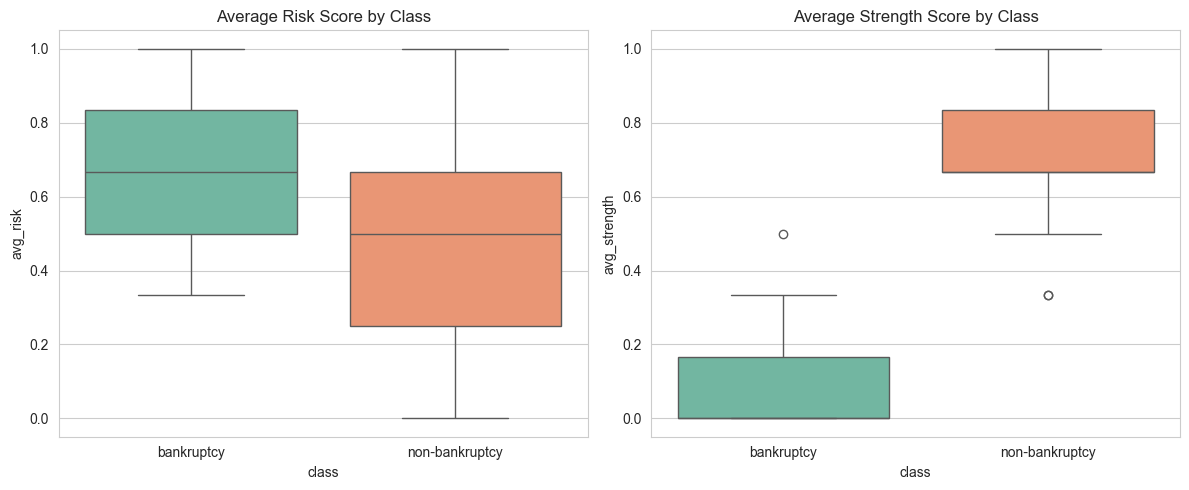

In [24]:
# Average of the 3 risk-type features and the 3 strength-type features
df["avg_risk"] = df[["industrial_risk", "management_risk", "operating_risk"]].mean(axis=1)
df["avg_strength"] = df[["financial_flexibility", "credibility", "competitiveness"]].mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x="class", y="avg_risk", hue="class", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Average Risk Score by Class")

sns.boxplot(data=df, x="class", y="avg_strength", hue="class", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Average Strength Score by Class")

plt.tight_layout()
plt.show()

**Observation:** Bankrupt companies clearly show a **higher average risk
score** and a **lower average strength score** compared to non-bankrupt
companies — exactly what we'd expect intuitively, and a good confirmation that
the dataset is internally consistent.

## 10. Summary of Findings

- The dataset contains **250 companies** with **6 qualitative features** and
  1 binary target (`class`), with **no missing values**.
- All 6 features are ordinal, taking only the values **0 (low), 0.5 (medium),
  1 (high)**.
- The target classes are **moderately imbalanced**: ~57% non-bankruptcy vs
  ~43% bankruptcy.
- `management_risk`, `financial_flexibility`, `credibility`, and
  `competitiveness` show the strongest visual and correlational separation
  between the two classes, making them likely to be the most important
  predictors.
- A simple combined "average risk" vs "average strength" score already shows
  clear separation between bankrupt and non-bankrupt companies, suggesting
  that even simple models (e.g. Logistic Regression, Decision Tree) should
  perform well on this dataset.